# TSA Assignment-1 📈

This notebook performs time series forecasting using ARIMA and Prophet for the AirQualityUCI dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
file_path = '/content/AirQualityUCI.xlsx'
df_raw = pd.read_excel(file_path)

# Merge Date and Time
df_raw['Datetime'] = pd.to_datetime(df_raw['Date'].astype(str) + ' ' + df_raw['Time'].astype(str), errors='coerce')
df_raw.set_index('Datetime', inplace=True)
df_raw.drop(columns=['Date', 'Time'], inplace=True)

# Replace -200 with NaN and interpolate
df = df_raw.replace(-200, np.nan).interpolate()

# Drop NMHC(GT) due to too many NaNs
if 'NMHC(GT)' in df.columns:
    df.drop(columns=['NMHC(GT)'], inplace=True)

df.head()


,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
Datetime,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.00,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
2004-03-10 19:00:00,2.0,1292.25,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2004-03-10 20:00:00,2.2,1402.00,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
2004-03-10 21:00:00,2.2,1375.50,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
2004-03-10 22:00:00,1.6,1272.25,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [2]:
target_columns = [
    "CO(GT)", "PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)", "NOx(GT)", "PT08.S3(NOx)",
    "NO2(GT)", "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"
]

n_total = len(df)
n_val = int(n_total * 0.1)

df_train = df.iloc[:-n_val]
df_val = df.iloc[-n_val:]
forecast_horizon = 48


In [8]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import pandas as pd

arima_rmse = {}
arima_forecasts = {}

for col in target_columns:
    try:
        # Ensure the index is datetime and has lowercase frequency
        series = df_train[col].copy()
        series.index = pd.to_datetime(series.index)
        series = series.asfreq('h')  # use 'h' instead of 'H'

        model = ARIMA(series, order=(1, 1, 1))
        model_fit = model.fit()

        forecast = model_fit.forecast(steps=forecast_horizon)
        arima_forecasts[col] = forecast

        true = df_val[col].iloc[:forecast_horizon]
        arima_rmse[col] = mean_squared_error(true, forecast) ** 0.5

    except Exception as e:
        print(f"ARIMA failed for {col}: {e}")
        arima_rmse[col] = None


In [12]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

prophet_rmse = {}
prophet_forecasts = {}

for col in target_columns:
    try:
        # Prepare the data
        df_prophet = df_train[[col]].reset_index().rename(columns={'Datetime': 'ds', col: 'y'})

        # Initialize and fit the Prophet model
        model = Prophet()
        model.fit(df_prophet)

        # Create future dataframe with lowercase frequency code
        future = model.make_future_dataframe(periods=forecast_horizon, freq='h')

        # Predict and extract the forecast
        forecast = model.predict(future)[['ds', 'yhat']].set_index('ds').iloc[-forecast_horizon:]
        prophet_forecasts[col] = forecast['yhat']

        # Compute RMSE manually
        true = df_val[col].iloc[:forecast_horizon]
        prophet_rmse[col] = mean_squared_error(true, forecast['yhat']) ** 0.5

    except Exception as e:
        print(f"Prophet failed for {col}: {e}")
        prophet_rmse[col] = None

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpozjyr4o1/7c3ed5z_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpozjyr4o1/5jzjlq20.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=27416', 'data', 'file=/tmp/tmpozjyr4o1/7c3ed5z_.json', 'init=/tmp/tmpozjyr4o1/5jzjlq20.json', 'output', 'file=/tmp/tmpozjyr4o1/prophet_modelyf3pr_7q/prophet_model-20250501225406.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
22:54:06 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
22:54:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/t

In [13]:
import openpyxl

results = []
for col in target_columns:
    a_rmse = arima_rmse.get(col)
    p_rmse = prophet_rmse.get(col)
    best = 'ARIMA' if (a_rmse or float('inf')) < (p_rmse or float('inf')) else 'Prophet'
    results.append([col, a_rmse, p_rmse, best])

eval_df = pd.DataFrame(results, columns=["Variable", "ARIMA_RMSE", "Prophet_RMSE", "Best_Model"])
eval_df.to_excel("submission.xlsx", sheet_name="Model_Evaluation", index=False)
eval_df


,Variable,ARIMA_RMSE,Prophet_RMSE,Best_Model
0,CO(GT),1.054449,0.899328,Prophet
1,PT08.S1(CO),199.900432,134.306618,Prophet
2,C6H6(GT),6.056060,4.135146,Prophet
3,PT08.S2(NMHC),248.298784,160.928149,Prophet
4,NOx(GT),162.249361,119.705778,Prophet
5,PT08.S3(NOx),219.578157,144.341856,Prophet
6,NO2(GT),72.776271,40.060580,Prophet
7,PT08.S4(NO2),263.459978,201.951732,Prophet
8,PT08.S5(O3),401.052480,271.042902,Prophet
9,T,3.699163,1.765985,Prophet


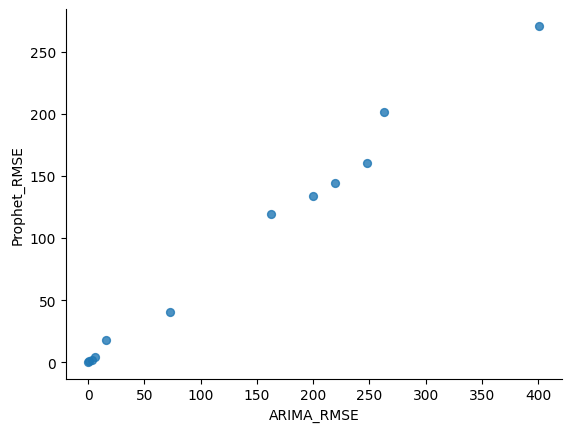

In [14]:
# @title ARIMA_RMSE vs Prophet_RMSE

from matplotlib import pyplot as plt
eval_df.plot(kind='scatter', x='ARIMA_RMSE', y='Prophet_RMSE', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)